# Libraries

**Environment**

In [1]:
!pip install -r https://raw.githubusercontent.com/Abdelrahmanemam01/Sentiment-Analysis/main/DistilBERT/requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.4/109.4 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 86.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 99.5 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.1/162.1 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.0/409.0 kB 28.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 116.2 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 89.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 51.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 8.9 M

**Imports**

In [2]:
# Standard Library Imports
import os
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# PyTorch
import torch

# Hugging Face Datasets & Transformers
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback,
    set_seed,
    pipeline
)

from sklearn.utils.class_weight import compute_class_weight

# Hugging Face Hub & Kaggle
from huggingface_hub import login
from kaggle_secrets import UserSecretsClient

# Evaluation Metrics
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

2025-12-19 19:35:43.162015: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1766172943.351688      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766172943.405687      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


# HyperParameters

In [3]:
SEED = 42
model_ckpt = "distilbert-base-uncased"
dataset_name = "emotion"
num_labels = 6
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Model Configurations
model_name = f"{model_ckpt}-finetuned-emotion"
batch_size = 32
epochs = 10
lr = 2e-5
w_decay = 0.01
PATIENCE = 3

# Functions

In [4]:
# Reproducibility
def set_all_seeds(seed: int) -> None:
    """Set seeds for full reproducibility."""
    
    # Python & NumPy
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)

    # PyTorch (CPU & GPU)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # cuDNN (deterministic behavior)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


# Label Utilities
def add_label_names(
    df: pd.DataFrame,
    label_column: str,
    label_feature,
    new_column: str = "label_name",
) -> pd.DataFrame:
    """Add human-readable label names to a DataFrame."""
    
    df[new_column] = df[label_column].apply(label_feature.int2str)
    return df


# Tokenization
def make_tokenize_fn(max_length: int):
    """Create a tokenizer function with fixed max length."""
    
    def tokenize(batch):
        return tokenizer(
            batch["text"],
            padding="max_length",
            truncation=True,
            max_length=max_length,
        )

    return tokenize


# Metrics
def compute_metrics(pred):
    """Compute evaluation metrics for Trainer."""
    
    labels = pred.label_ids
    preds = pred.predictions.argmax(axis=-1)

    return {
        "f1_macro": f1_score(labels, preds, average="macro"),
        "accuracy": accuracy_score(labels, preds),
    }

# Classes

In [5]:
class WeightedTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.loss_fct = torch.nn.CrossEntropyLoss(
            weight=class_weights
        )

    def compute_loss(self, model, inputs, return_outputs=False):
        labels = inputs["labels"]
        outputs = model(**inputs)
        logits = outputs.logits

        loss = self.loss_fct(logits, labels)
        return (loss, outputs) if return_outputs else loss

# Seed for reproducibility

In [6]:
set_all_seeds(SEED)

# Hugging Face

In [7]:
# NOTE:
# To push to Hugging Face Hub, make sure you're logged in:
# huggingface-cli login

# Preprocessing & Visualization

**Load Dataset**

In [8]:
emotions = load_dataset(dataset_name)

README.md: 0.00B [00:00, ?B/s]

split/train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

split/validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

split/test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [9]:
emotions

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [10]:
train_ds = emotions['train']
val_ds = emotions['validation']
test_ds = emotions['test']

train_ds[:5]

{'text': ['i didnt feel humiliated',
  'i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake',
  'im grabbing a minute to post i feel greedy wrong',
  'i am ever feeling nostalgic about the fireplace i will know that it is still on the property',
  'i am feeling grouchy'],
 'label': [0, 0, 3, 2, 3]}

**Change to dataframe**

In [11]:
train_df = train_ds.to_pandas()

val_df = val_ds.to_pandas()

test_df = test_ds.to_pandas()

train_df.head()

,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3


**Change label to class_name**

In [12]:
label_feature = emotions["train"].features["label"]

train_df = add_label_names(
    train_df,
    label_column="label",
    label_feature=label_feature
)

val_df = add_label_names(
    val_df,
    label_column="label",
    label_feature=label_feature
)

test_df = add_label_names(
    test_df,
    label_column="label",
    label_feature=label_feature
)

train_df.head()

,text,label,label_name
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger


**Check frequency of classes**

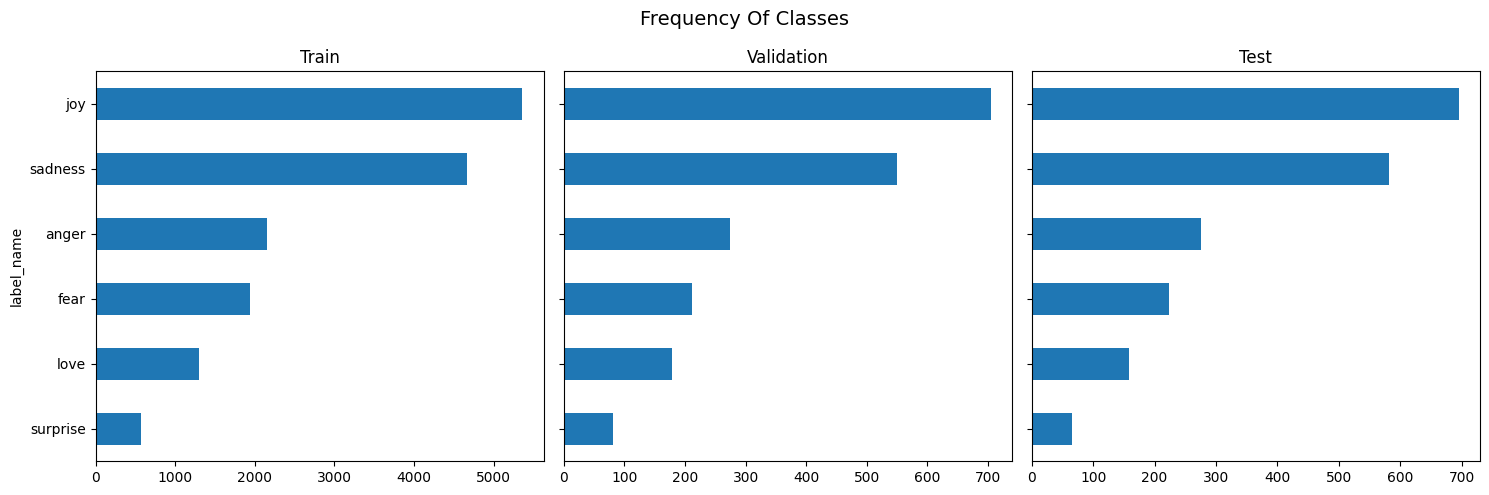

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

datasets = [
    (train_df, "Train"),
    (val_df, "Validation"),
    (test_df, "Test")
]

for ax, (df, name) in zip(axes, datasets):
    counts = df['label_name'].value_counts(ascending=True)
    counts.plot.barh(ax=ax)
    ax.set_title(name)

fig.suptitle("Frequency Of Classes", fontsize=14)
plt.tight_layout()
plt.show()

**Tweet's  Token Length**

In [14]:
# Load Tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

# Tokenization
encodings = tokenizer(
    train_df['text'].tolist(),
    padding=False,
    truncation=False
)

# Calculate Tokens Per Tweet
train_df['num_tokens'] = [len(ids) for ids in encodings['input_ids']]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

/usr/local/lib/python3.11/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [15]:
print("Maximum context size of DistilBert is ", tokenizer.model_max_length)

train_df['num_tokens'].describe()

Maximum context size of DistilBert is  512


count    16000.000000
mean        22.259500
std         11.575801
min          4.000000
25%         13.000000
50%         20.000000
75%         29.000000
max         87.000000
Name: num_tokens, dtype: float64

**Limit Tweets to Max_length**

In [16]:
p97 = int(np.percentile(train_df['num_tokens'], 97))
print("97% of my tweets is <= ", p97)
max_length = 64
tokenize = make_tokenize_fn(max_length)

97% of my tweets is <=  49


**Tokenization**

In [17]:
emotions_encoded = emotions.map(tokenize, batched=True, batch_size=None)
emotions_encoded = emotions_encoded.with_format("torch")

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

**Load Model**

In [18]:
set_all_seeds(SEED)
model = AutoModelForSequenceClassification.from_pretrained(model_ckpt, num_labels=num_labels).to(device)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


# Fine Tuning

**Weighted Class**

In [19]:
labels = np.array(emotions_encoded["train"]["label"])

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels),
    y=labels
)

# soften extreme weights
class_weights = np.sqrt(class_weights)

class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

**Training Arguments**

In [20]:
# Step calculation
eval_save_steps = len(emotions_encoded["train"]) // batch_size # evaluate & save once per epoch


# Training Arguments
training_args = TrainingArguments(
    # Output
    output_dir="/kaggle/working/tmp",
    num_train_epochs=epochs,

    # Optimization
    learning_rate=lr,
    weight_decay=w_decay,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,

    # Evaluation & Saving
    eval_strategy="steps",
    eval_steps=eval_save_steps,
    save_strategy="steps",
    save_steps=eval_save_steps,

    # Best Model Handling
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="eval_f1_macro",
    greater_is_better=True,

    # Logging
    logging_strategy="steps",
    logging_steps=eval_save_steps,
    logging_first_step=True,
    log_level="error",

    # Misc
    disable_tqdm=False,
    report_to="none",

    # Hugging Face Hub
    push_to_hub=False
)


# Trainer
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=emotions_encoded["train"],
    eval_dataset=emotions_encoded["validation"],
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
    class_weights=class_weights,
    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=PATIENCE
        )
    ]
)

**Training**

In [21]:
# Train
trainer.train()


# Final Evaluation
# Best checkpoint is already loaded because:
# load_best_model_at_end=True

# Validation
val_metrics = trainer.evaluate()
trainer.log_metrics("eval", val_metrics)
trainer.save_metrics("eval", val_metrics)

# Test
test_metrics = trainer.evaluate(emotions_encoded["test"])
trainer.log_metrics("test", test_metrics)
trainer.save_metrics("test", test_metrics)


# Push to Hub
try:
    trainer.push_to_hub()
except Exception:
    print("Not logged in to Hugging Face — skipping push_to_hub")

Step,Training Loss,Validation Loss,F1 Macro,Accuracy
500,0.644500,0.237418,0.899262,0.923500
1000,0.181100,0.168337,0.910885,0.934000
1500,0.135700,0.168638,0.915664,0.938000
2000,0.103600,0.173698,0.919236,0.940000
2500,0.081600,0.220371,0.908564,0.934500
3000,0.062900,0.219666,0.914244,0.938500
3500,0.047500,0.306352,0.908097,0.935500


***** eval metrics *****
  epoch                   =        7.0
  eval_accuracy           =       0.94
  eval_f1_macro           =     0.9192
  eval_loss               =     0.1737
  eval_runtime            = 0:00:01.91
  eval_samples_per_second =    1041.84
  eval_steps_per_second   =     32.818
***** test metrics *****
  epoch                   =        7.0
  eval_accuracy           =      0.927
  eval_f1_macro           =     0.8902
  eval_loss               =     0.2094
  eval_runtime            = 0:00:01.97
  eval_samples_per_second =   1011.245
  eval_steps_per_second   =     31.854
Not logged in to Hugging Face — skipping push_to_hub


**Validation Set**

**Classification Report**

In [22]:
# Get predictions on validation set
preds_output = trainer.predict(emotions_encoded["validation"])

y_val_true = preds_output.label_ids
y_val_pred = np.argmax(preds_output.predictions, axis=1)

# Class names
label_names = emotions["validation"].features["label"].names

val_report = classification_report(
    y_val_true,
    y_val_pred,
    target_names=label_names,
    digits=3
)

print(val_report)

              precision    recall  f1-score   support

     sadness      0.960     0.971     0.966       550
         joy      0.985     0.930     0.957       704
        love      0.828     0.949     0.885       178
       anger      0.959     0.931     0.945       275
        fear      0.899     0.882     0.890       212
    surprise      0.790     0.975     0.873        81

    accuracy                          0.940      2000
   macro avg      0.904     0.940     0.919      2000
weighted avg      0.944     0.940     0.941      2000



**Confusion Matrix**

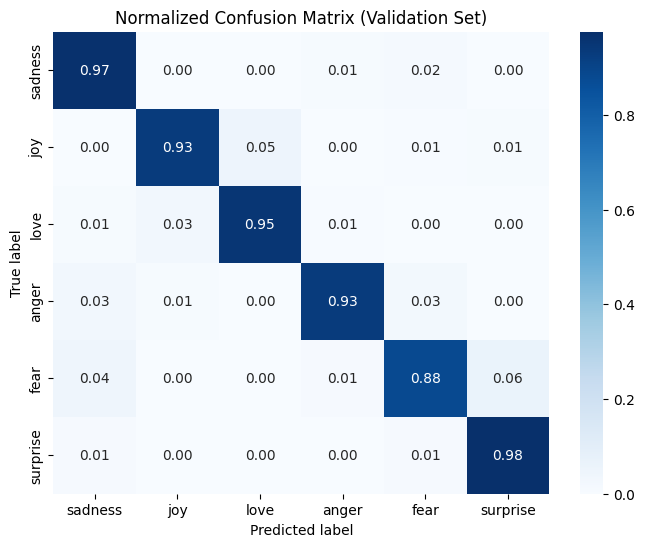

In [23]:
# Normalized confusion matrix
cm_norm = confusion_matrix(
    y_val_true,
    y_val_pred,
    normalize="true"
)

# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=label_names,
    yticklabels=label_names
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Normalized Confusion Matrix (Validation Set)")

# Save BEFORE show
plt.savefig(
    "confusion_matrix_validation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Test Set**

**Classification Report**

In [24]:
# Get predictions on test set
preds_output = trainer.predict(emotions_encoded["test"])

y_test_true = preds_output.label_ids
y_test_pred = np.argmax(preds_output.predictions, axis=1)

# Class names
label_names = emotions["test"].features["label"].names

test_report = classification_report(
    y_test_true,
    y_test_pred,
    target_names=label_names,
    digits=3
)

print(test_report)

              precision    recall  f1-score   support

     sadness      0.956     0.972     0.964       581
         joy      0.979     0.925     0.951       695
        love      0.791     0.931     0.855       159
       anger      0.933     0.905     0.919       275
        fear      0.912     0.835     0.872       224
    surprise      0.667     0.939     0.780        66

    accuracy                          0.927      2000
   macro avg      0.873     0.918     0.890      2000
weighted avg      0.933     0.927     0.928      2000



**Confusion Matrix**

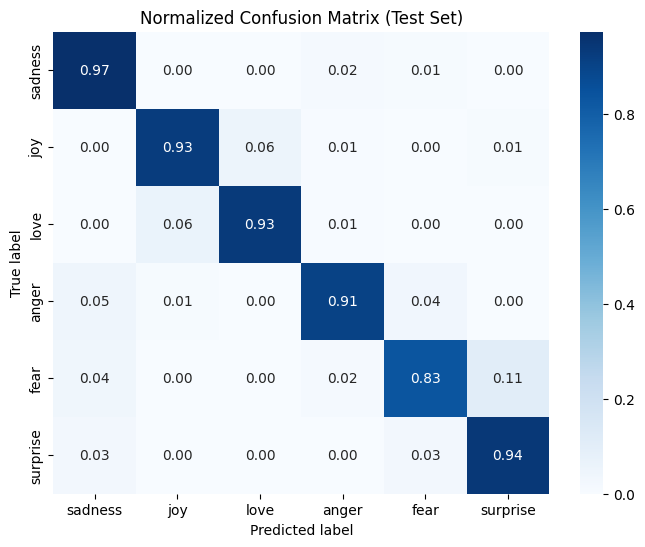

In [25]:
# Normalized confusion matrix (each row sums to 1)
cm_norm = confusion_matrix(
    y_test_true,
    y_test_pred,
    normalize="true"
)

# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=label_names,
    yticklabels=label_names
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Normalized Confusion Matrix (Test Set)")

# Save BEFORE show
plt.savefig(
    "confusion_matrix_test.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Evaluation

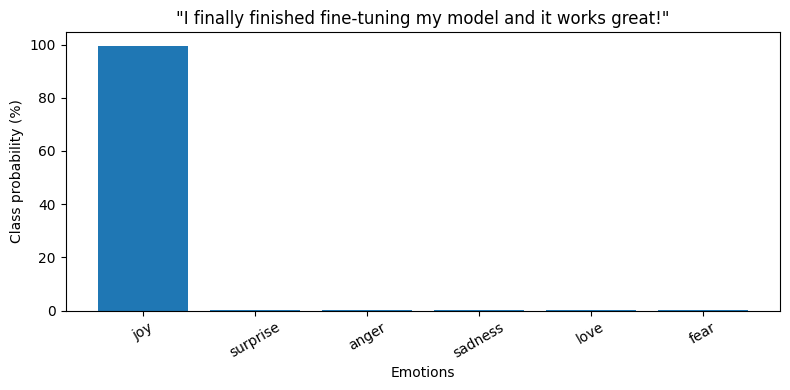

In [27]:
# Load pipeline
model_id = "abdelrahmane01/SentimentAnalysis-distilbert-base-uncased-finetuned-emotion"
classifier = pipeline(
    "text-classification",
    model=model_id,
    device=0
)

# Input text
tweet = "I finally finished fine-tuning my model and it works great!"

# Inference: get all class probabilities
predictions = classifier(tweet, top_k=None)

# Convert to DataFrame
preds_df = pd.DataFrame(predictions)

# Plot
plt.figure(figsize=(8, 4))
plt.bar(preds_df["label"], preds_df["score"] * 100)

plt.title(f'"{tweet}"')
plt.ylabel("Class probability (%)")
plt.xlabel("Emotions")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()